In [1]:
import numpy as np
import pandas as pd
import xarray as xr
from functools import reduce
import matplotlib.pyplot as plt
from idlpy import *
from scipy import stats
import statsmodels.api as sm

seasons = ['summer','autumn','winter','spring']

IDL 8.7.2 (linux x86_64 m64).
(c) 2019, Harris Geospatial Solutions, Inc.

A new version is available: IDL 8.9
https://www.l3harrisgeospatial.com/Product-Downloads/
 
Licensed for use by: NIWA - National Institute of Water and Atmospheric Research Ltd - Ashley
License: 229483-BUF
Expiration date: 31-Mar-2024


In [9]:
df = pd.read_csv("/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/summary_csv/tasmax_annual_trunc_36.csv")

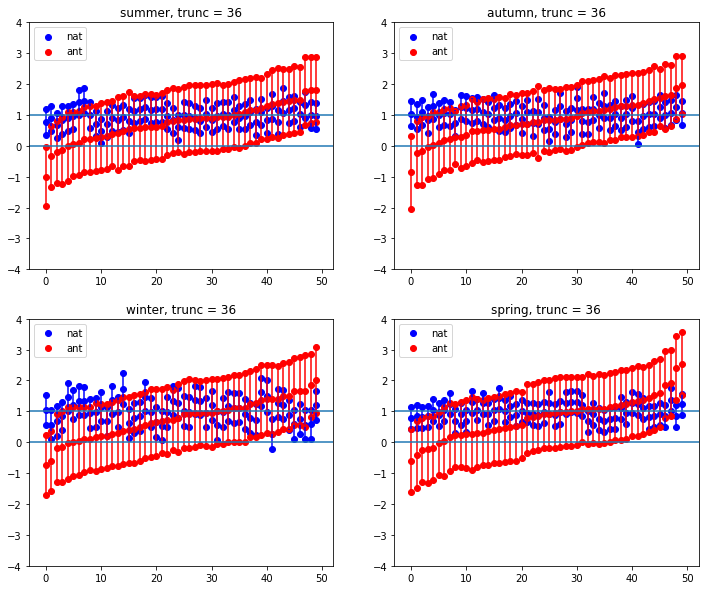

In [12]:

sort_type = 'ant_best'

fig,axs = plt.subplots(2,2, figsize=(12,10))
axs = axs.flatten()

for i,s in enumerate(seasons):

    sorted_df = df.loc[df['season'] == s].sort_values(by=sort_type)

    axs[i].scatter([i for i in range(len(sorted_df.nat_upper))],sorted_df.nat_upper,c='blue',label='nat')
    axs[i].scatter([i for i in range(len(sorted_df.nat_lower))],sorted_df.nat_lower,c='blue',label='')
    axs[i].scatter([i for i in range(len(sorted_df.nat_best))],sorted_df.nat_best,c='blue',label='')

    axs[i].scatter([i for i in range(len(sorted_df.ant_upper))],sorted_df.ant_upper,c='red',label='ant')
    axs[i].scatter([i for i in range(len(sorted_df.ant_lower))],sorted_df.ant_lower,c='red',label='')
    axs[i].scatter([i for i in range(len(sorted_df.ant_best))],sorted_df.ant_best,c='red',label='')

    axs[i].vlines([i for i in range(len(sorted_df.nat_lower))],sorted_df.nat_lower,sorted_df.nat_upper,colors=['blue'],label='')
    axs[i].vlines([i for i in range(len(sorted_df.ant_lower))],sorted_df.ant_lower,sorted_df.ant_upper,colors=['red'],label='')

    axs[i].axhline(0,-0.5,1.5)
    axs[i].axhline(1,-0.5,1.5)

    axs[i].set_title(s + ', trunc = 36')

    axs[i].legend()

    axs[i].set_ylim(-4,4)
    
plt.savefig("/nesi/project/niwa00015/queenle/plots/perfect_model/ECHAM5/temperature/seasonal/annual/PM_ensemble_summary_ant_best_sort.png",dpi=300)

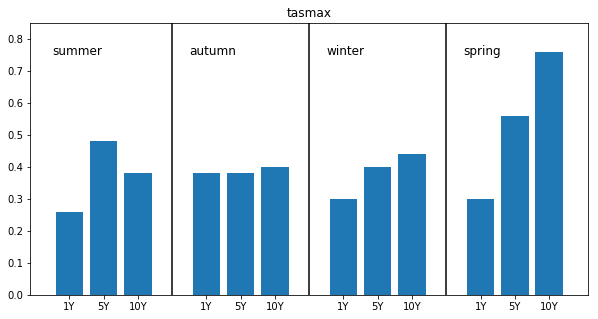

In [66]:
'''
Success rate comparison over temporal resampling averages (1,5,10 years) for tasmax, pr, sro
'''

for var in ['tasmax']:#,'pr','sro']:
    fig,ax = plt.subplots(figsize=(10,5))

    annual_df = pd.read_csv("/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/summary_csv/"+var+"_annual_trunc_36.csv")
    Y5_df = pd.read_csv("/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/summary_csv/"+var+"_5Y_trunc_36.csv")
    Y10_df = pd.read_csv("/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/summary_csv/"+var+"_10Y_trunc_36.csv")

    heights = []
    labels = []
    for i,s in enumerate(seasons):
        # annual
        heights.append((annual_df.loc[annual_df['season'] == s]['ant_lower']>0).sum()/len(annual_df.loc[annual_df['season'] == s]))
        labels.append('1Y')
        # 5Y
        heights.append((Y5_df.loc[Y5_df['season'] == s]['ant_lower']>0).sum()/len(Y5_df.loc[Y5_df['season'] == s]))
        labels.append("5Y")
        # 10Y
        heights.append((Y10_df.loc[Y10_df['season'] == s]['ant_lower']>0).sum()/len(Y10_df.loc[Y10_df['season'] == s]))
        labels.append("10Y")

        ax.text(1 + 4*i - 0.5,0.75,s,fontsize=12)


    ticks = [1,2,3,5,6,7,9,10,11,13,14,15]
    ax.bar(ticks,heights)
    ax.set_xticks(ticks)
    ax.set_xticklabels(labels)

    ax.vlines([4,8,12],0,0.85)
    ax.set_ylim(0,0.85)
    
    ax.set_title(var)


(0, 0.85)

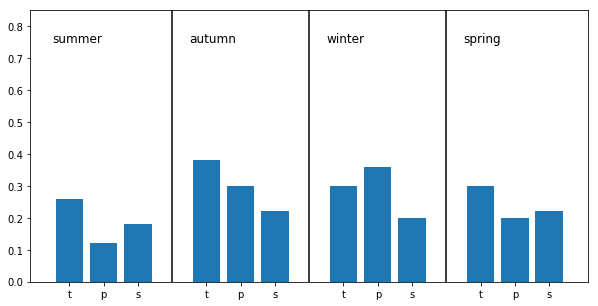

In [20]:
'''
Success rate comparison over temporal resampling averages (1,5,10 years) for tasmax, pr, sro
'''

fig,ax = plt.subplots(figsize=(10,5))

t_df = pd.read_csv("/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/summary_csv/tasmax_annual_trunc_36.csv")
p_df = pd.read_csv("/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/summary_csv/pr_annual_trunc_36.csv")
s_df = pd.read_csv("/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/summary_csv/sro_annual_trunc_36.csv")

heights = []
labels = []
for i,s in enumerate(seasons):
    # annual
    heights.append((t_df.loc[t_df['season'] == s]['ant_lower']>0).sum()/len(t_df.loc[t_df['season'] == s]))
    labels.append('t')
    # 5Y
    heights.append((p_df.loc[p_df['season'] == s]['ant_lower']>0).sum()/len(p_df.loc[p_df['season'] == s]))
    labels.append("p")
    # 10Y
    heights.append((s_df.loc[s_df['season'] == s]['ant_lower']>0).sum()/len(s_df.loc[s_df['season'] == s]))
    labels.append("s")

    ax.text(1 + 4*i - 0.5,0.75,s,fontsize=12)


ticks = [1,2,3,5,6,7,9,10,11,13,14,15]
ax.bar(ticks,heights)
ax.set_xticks(ticks)
ax.set_xticklabels(labels)

ax.vlines([4,8,12],0,0.85)
ax.set_ylim(0,0.85)



/opt/nesi/CS500_centos7_skl/Anaconda3/5.2.0-GCC-7.1.0/lib/python3.6/site-packages/matplotlib/figure.py:2369: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  warnings.warn("This figure includes Axes that are not compatible "


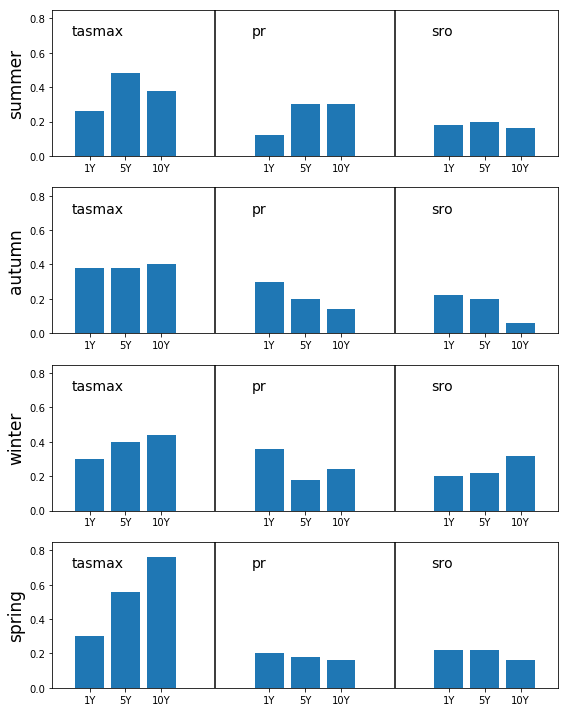

In [18]:
'''
Success rate comparison over variables
'''

fig,axs = plt.subplots(4,1,figsize=(8,10),tight_layout=True)
axs = axs.flatten()

for i,s in enumerate(seasons):
    
    heights = []
    labels = []
    
    for j,var in enumerate(['tasmax','pr','sro']):
        
        annual_df = pd.read_csv("/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/summary_csv/"+var+"_annual_trunc_36.csv")
        Y5_df = pd.read_csv("/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/summary_csv/"+var+"_5Y_trunc_36.csv")
        Y10_df = pd.read_csv("/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/summary_csv/"+var+"_10Y_trunc_36.csv")


        # tasmax
        heights.append((annual_df.loc[annual_df['season'] == s]['ant_lower']>0).sum()/len(annual_df.loc[annual_df['season'] == s]))
        labels.append('1Y')
        # pr
        heights.append((Y5_df.loc[Y5_df['season'] == s]['ant_lower']>0).sum()/len(Y5_df.loc[Y5_df['season'] == s]))
        labels.append('5Y')
        # sro
        heights.append((Y10_df.loc[Y10_df['season'] == s]['ant_lower']>0).sum()/len(Y10_df.loc[Y10_df['season'] == s]))
        labels.append('10Y')
        axs[i].text(1 + 5*j - 0.5,0.7,var,fontsize=14)


    ticks = [1,2,3,6,7,8,11,12,13]
    axs[i].bar(ticks,heights)
    axs[i].set_xticks(ticks)
    axs[i].set_xticklabels(labels)
    
    axs[i].set_ylabel(s,fontsize=17)

    axs[i].vlines([4.5,9.5],0,0.85)
    axs[i].set_ylim(0,0.85)
    
    #axs[i].set_title(var)


/opt/nesi/CS500_centos7_skl/Anaconda3/5.2.0-GCC-7.1.0/lib/python3.6/site-packages/matplotlib/figure.py:2369: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  warnings.warn("This figure includes Axes that are not compatible "


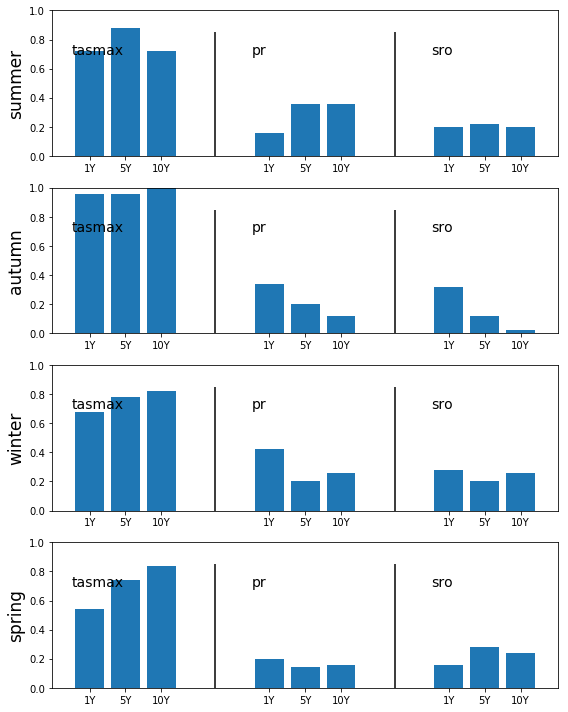

In [7]:
'''
Success rate comparison over variables
'''

fig,axs = plt.subplots(4,1,figsize=(8,10),tight_layout=True)
axs = axs.flatten()

for i,s in enumerate(seasons):
    
    heights = []
    labels = []
    
    for j,var in enumerate(['tasmax','pr','sro']):
        
        if var in ['pr','sro']:
            annual_df = pd.read_csv("/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/summary_csv/detrend_nat_trend_all/mem_in_mean/"+var+"_annual_trunc_36.csv")
            Y5_df = pd.read_csv("/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/summary_csv/detrend_nat_trend_all/mem_in_mean/"+var+"_5Y_trunc_36.csv")
            Y10_df = pd.read_csv("/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/summary_csv/detrend_nat_trend_all/mem_in_mean/"+var+"_10Y_trunc_36.csv")
        else:
            annual_df = pd.read_csv("/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/summary_csv/detrend_nat_trend_all/"+var+"_annual_trunc_36.csv")
            Y5_df = pd.read_csv("/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/summary_csv/detrend_nat_trend_all/"+var+"_5Y_trunc_36.csv")
            Y10_df = pd.read_csv("/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/summary_csv/detrend_nat_trend_all/"+var+"_10Y_trunc_36.csv")


        # tasmax
        heights.append((annual_df.loc[annual_df['season'] == s]['ant_lower']>0).sum()/len(annual_df.loc[annual_df['season'] == s]))
        labels.append('1Y')
        # pr
        heights.append((Y5_df.loc[Y5_df['season'] == s]['ant_lower']>0).sum()/len(Y5_df.loc[Y5_df['season'] == s]))
        labels.append('5Y')
        # sro
        heights.append((Y10_df.loc[Y10_df['season'] == s]['ant_lower']>0).sum()/len(Y10_df.loc[Y10_df['season'] == s]))
        labels.append('10Y')
        axs[i].text(1 + 5*j - 0.5,0.7,var,fontsize=14)


    ticks = [1,2,3,6,7,8,11,12,13]
    axs[i].bar(ticks,heights)
    axs[i].set_xticks(ticks)
    axs[i].set_xticklabels(labels)
    
    axs[i].set_ylabel(s,fontsize=17)

    axs[i].vlines([4.5,9.5],0,0.85)
    axs[i].set_ylim(0,1)
    
    #axs[i].set_title(var)


In [22]:
df

,Unnamed: 0,ensemble_member,season,ant_upper,ant_lower,ant_best,nat_upper,nat_lower,nat_best
0,0,1,summer,1.638015,-0.428148,0.604933,1.580710,0.772830,1.176770
1,1,1,autumn,1.698819,-0.314611,0.692104,1.296036,0.415339,0.855688
2,2,1,winter,2.077538,-0.053781,1.011879,1.419939,0.507361,0.963650
3,3,1,spring,2.195701,-0.040548,1.077577,1.105544,0.411283,0.758413
4,4,2,summer,2.033917,-0.185929,0.923994,1.378337,0.551477,0.964907
...,...,...,...,...,...,...,...,...,...
195,195,49,spring,2.394183,0.208460,1.301321,1.626859,0.931634,1.279246
196,196,50,summer,1.302604,-0.820742,0.240931,1.125052,0.314578,0.719815
197,197,50,autumn,1.810682,-0.166039,0.822321,1.306219,0.501441,0.903830
198,198,50,winter,2.558869,0.435498,1.497184,1.691412,0.741838,1.216625
